# TC4 钛合金分段式应变补偿 Arrhenius 本构模型

- 882°C 相变点物理分段
- 自适应异常点剔除回归（R² ≥ 0.95）
- 三次样条插值 + 5次多项式连续化

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

R_GAS = 8.314  # J/(mol·K)
PHASE_BOUNDARY = 882  # °C

---
## 1. 自适应异常点剔除线性回归引擎

R² < 0.95 时迭代剔除残差最大点，直到 R² ≥ 0.95 或点数 ≤ 3

In [2]:
def adaptive_linregress(x, y, r2_threshold=0.95, min_points=3, verbose=False):
    """
    自适应异常点剔除线性回归。
    返回: slope, intercept, r_squared, kept_mask(布尔数组，标记保留的点)
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.ones(len(x), dtype=bool)

    iteration = 0
    while True:
        xm, ym = x[mask], y[mask]
        if len(xm) < 2:
            break
        slope, intercept, r_value, _, _ = linregress(xm, ym)
        r2 = r_value ** 2

        if verbose:
            print(f'  迭代{iteration}: {len(xm)}点, R²={r2:.6f}, slope={slope:.6f}')

        if r2 >= r2_threshold or len(xm) <= min_points:
            return slope, intercept, r2, mask

        residuals = np.abs(ym - (slope * xm + intercept))
        worst_local = np.argmax(residuals)
        global_indices = np.where(mask)[0]
        mask[global_indices[worst_local]] = False
        iteration += 1

    xm, ym = x[mask], y[mask]
    if len(xm) >= 2:
        slope, intercept, r_value, _, _ = linregress(xm, ym)
        return slope, intercept, r_value ** 2, mask
    return np.nan, np.nan, 0.0, mask


# 验证
x_test = np.array([1, 2, 3, 4, 5, 6])
y_test = np.array([2.1, 3.9, 6.2, 7.8, 10.1, 50.0])  # 第6点是异常点
s, i, r2, m = adaptive_linregress(x_test, y_test, verbose=True)
print(f'最终: slope={s:.4f}, intercept={i:.4f}, R²={r2:.4f}, 保留点={m}')

  迭代0: 6点, R²=0.583375, slope=7.420000
  迭代1: 5点, R²=0.997305, slope=1.990000
最终: slope=1.9900, intercept=0.0500, R²=0.9973, 保留点=[ True  True  True  True  True False]


---
## 2. 数据加载与物理温区分流

In [3]:
file_path = '/Users/bertonyang/project/chenglu/data/TC4_0219.xlsx'
xlsx = pd.ExcelFile(file_path)

all_data = []
for sheet_name in xlsx.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    temp = int(sheet_name)
    num_pairs = df.shape[1] // 2
    for i in range(num_pairs):
        strain_rate = float(df.iloc[0, i * 2])
        strain = pd.to_numeric(df.iloc[1:, i * 2], errors='coerce')
        stress = pd.to_numeric(df.iloc[1:, i * 2 + 1], errors='coerce')
        for s_val, r_val in zip(strain, stress):
            if pd.notna(s_val) and pd.notna(r_val):
                all_data.append({
                    'Temperature': temp,
                    'T_K': temp + 273.15,
                    'StrainRate': strain_rate,
                    'TrueStrain': s_val,
                    'FlowStress': r_val
                })

df_all = pd.DataFrame(all_data)
df_all = df_all[(df_all['FlowStress'] > 0) & (df_all['TrueStrain'] > 0)].copy()

print(f'有效数据总量: {len(df_all)}')
print(f'温度(°C): {sorted(df_all["Temperature"].unique())}')
print(f'应变速率: {sorted(df_all["StrainRate"].unique())}')
print(f'\n--- 882°C 相变分段 ---')

df_low  = df_all[df_all['Temperature'] < PHASE_BOUNDARY].copy()
df_high = df_all[df_all['Temperature'] >= PHASE_BOUNDARY].copy()

temps_low  = sorted(df_low['Temperature'].unique())
temps_high = sorted(df_high['Temperature'].unique())
rates = sorted(df_all['StrainRate'].unique())

print(f'低温区 (α+β, <882°C): {temps_low}, {len(df_low)} 条')
print(f'高温区 (β, ≥882°C):  {temps_high}, {len(df_high)} 条')
print(f'应变速率: {rates}')

有效数据总量: 39109
温度(°C): [np.int64(800), np.int64(850), np.int64(900), np.int64(950), np.int64(980), np.int64(1010)]
应变速率: [np.float64(0.001), np.float64(0.01), np.float64(0.1), np.float64(1.0), np.float64(10.0)]

--- 882°C 相变分段 ---
低温区 (α+β, <882°C): [np.int64(800), np.int64(850)], 15718 条
高温区 (β, ≥882°C):  [np.int64(900), np.int64(950), np.int64(980), np.int64(1010)], 23391 条
应变速率: [np.float64(0.001), np.float64(0.01), np.float64(0.1), np.float64(1.0), np.float64(10.0)]


In [4]:
# 各条件数据概览
for zone_name, df_zone, t_list in [('低温区', df_low, temps_low), ('高温区', df_high, temps_high)]:
    print(f'\n=== {zone_name} ===')
    for t in t_list:
        for sr in rates:
            sub = df_zone[(df_zone['Temperature'] == t) & (df_zone['StrainRate'] == sr)]
            if len(sub) > 0:
                print(f'  T={t}°C, ε̇={sr}: {len(sub):>5d} 行, '
                      f'ε=[{sub["TrueStrain"].min():.4f},{sub["TrueStrain"].max():.4f}], '
                      f'σ=[{sub["FlowStress"].min():.1f},{sub["FlowStress"].max():.1f}] MPa')


=== 低温区 ===
  T=800°C, ε̇=0.001:  1381 行, ε=[0.0000,0.6873], σ=[2.3,79.3] MPa
  T=800°C, ε̇=0.01:  1393 行, ε=[0.0000,0.6782], σ=[3.1,157.7] MPa
  T=800°C, ε̇=0.1:  3421 行, ε=[0.0000,0.6809], σ=[2.3,299.9] MPa
  T=800°C, ε̇=1.0:  1483 行, ε=[0.0001,0.6934], σ=[1.5,340.3] MPa
  T=800°C, ε̇=10.0:   170 行, ε=[0.0000,0.6880], σ=[0.6,390.9] MPa
  T=850°C, ε̇=0.001:  3502 行, ε=[0.0000,0.7000], σ=[2.4,38.9] MPa
  T=850°C, ε̇=0.01:  1405 行, ε=[0.0000,0.7002], σ=[1.8,108.0] MPa
  T=850°C, ε̇=0.1:  1405 行, ε=[0.0000,0.6990], σ=[1.5,171.4] MPa
  T=850°C, ε̇=1.0:  1410 行, ε=[0.0000,0.6884], σ=[3.7,250.5] MPa
  T=850°C, ε̇=10.0:   148 行, ε=[0.0003,0.6850], σ=[2.6,269.8] MPa

=== 高温区 ===
  T=900°C, ε̇=0.001:  3508 行, ε=[0.0000,0.6999], σ=[3.4,30.9] MPa
  T=900°C, ε̇=0.01:  1394 行, ε=[0.0000,0.6927], σ=[1.0,63.5] MPa
  T=900°C, ε̇=0.1:  1398 行, ε=[0.0001,0.6979], σ=[1.8,123.0] MPa
  T=900°C, ε̇=1.0:  1400 行, ε=[0.0000,0.6777], σ=[1.7,162.7] MPa
  T=900°C, ε̇=10.0:   179 行, ε=[0.0002,0.6938], σ=[0.2,22

---
## 3. 三次样条插值提取离散应变点应力

In [5]:
strain_targets = np.arange(0.10, 0.705, 0.05)
print(f'目标应变序列: {np.round(strain_targets, 2)}')
print(f'共 {len(strain_targets)} 个应变点\n')


def interpolate_stress(df_zone, temps_list, rates_list, strain_targets):
    """三次样条插值，返回 dict: {(T, SR, eps): sigma}"""
    result = {}
    for temp in temps_list:
        for sr in rates_list:
            sub = df_zone[(df_zone['Temperature'] == temp) & (df_zone['StrainRate'] == sr)]
            sub = sub.sort_values('TrueStrain')
            grp = sub.groupby('TrueStrain')['FlowStress'].mean().reset_index()
            if len(grp) < 4:
                continue
            try:
                cs = CubicSpline(grp['TrueStrain'].values, grp['FlowStress'].values)
                for eps in strain_targets:
                    if grp['TrueStrain'].min() <= eps <= grp['TrueStrain'].max():
                        sigma = float(cs(eps))
                        if sigma > 0:
                            result[(temp, sr, round(eps, 4))] = sigma
            except Exception as e:
                print(f'  插值失败: T={temp}, SR={sr}: {e}')
    return result


table_low  = interpolate_stress(df_low,  temps_low,  rates, strain_targets)
table_high = interpolate_stress(df_high, temps_high, rates, strain_targets)

print(f'低温区插值点: {len(table_low)}')
print(f'高温区插值点: {len(table_high)}')

# 转为 DataFrame 方便后续使用
def table_to_df(table):
    rows = [{'Temperature': k[0], 'T_K': k[0]+273.15, 'StrainRate': k[1],
             'TrueStrain': k[2], 'FlowStress': v} for k, v in table.items()]
    return pd.DataFrame(rows)

df_disc_low  = table_to_df(table_low)
df_disc_high = table_to_df(table_high)

# 展示样例
print('\n--- 低温区 ε=0.3 处应力 (MPa) ---')
pv = df_disc_low[np.isclose(df_disc_low['TrueStrain'], 0.3)].pivot_table(
    index='Temperature', columns='StrainRate', values='FlowStress')
print(pv.round(2))

print('\n--- 高温区 ε=0.3 处应力 (MPa) ---')
pv = df_disc_high[np.isclose(df_disc_high['TrueStrain'], 0.3)].pivot_table(
    index='Temperature', columns='StrainRate', values='FlowStress')
print(pv.round(2))

目标应变序列: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7 ]
共 13 个应变点

低温区插值点: 121
高温区插值点: 239

--- 低温区 ε=0.3 处应力 (MPa) ---
StrainRate   0.001   0.010   0.100   1.000   10.000
Temperature                                        
800           59.84  132.36  249.96  319.63  385.71
850           36.07   92.71  166.73  233.91  260.94

--- 高温区 ε=0.3 处应力 (MPa) ---
StrainRate   0.001   0.010   0.100   1.000   10.000
Temperature                                        
900           27.38   56.36  108.65  143.24  213.46
950           14.55   22.89   50.61   73.40  117.15
980           13.68   23.43   39.09   67.77   96.13
1010          11.14   18.56   36.97   68.35   86.88


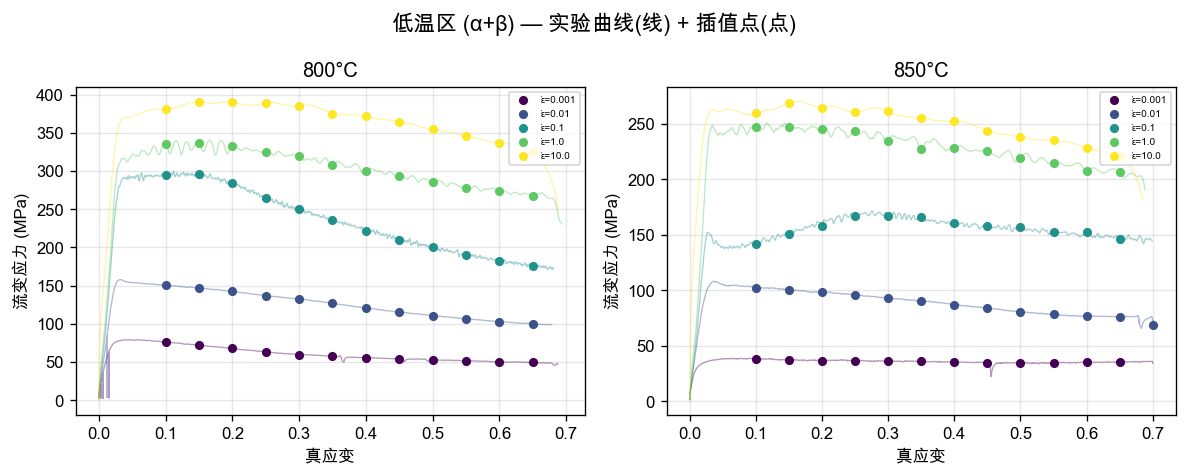

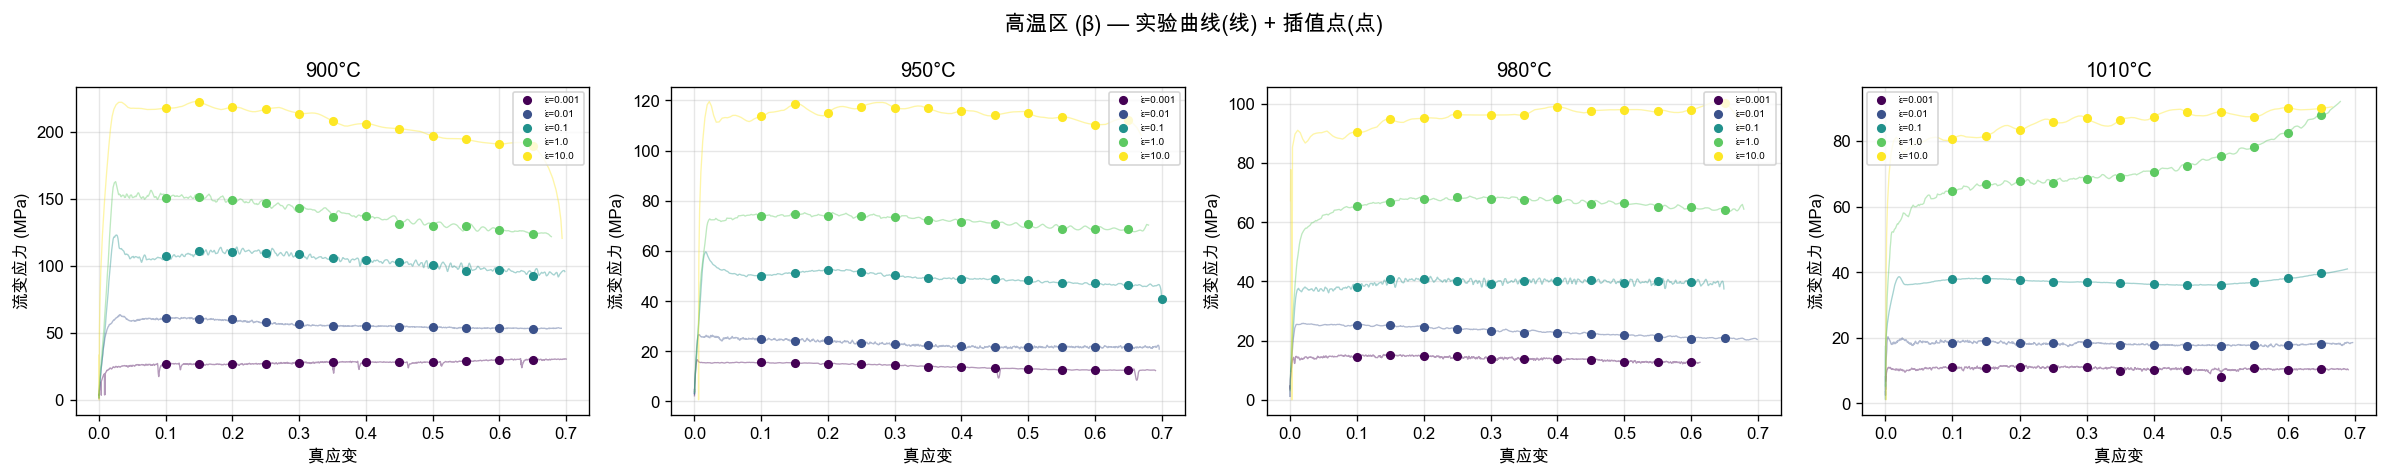

In [6]:
# 绘制实验应力-应变曲线 + 插值点验证
rate_colors = plt.cm.viridis(np.linspace(0, 1, len(rates)))

for zone_name, df_zone, df_disc, t_list in [
    ('低温区 (α+β)', df_low, df_disc_low, temps_low),
    ('高温区 (β)', df_high, df_disc_high, temps_high)
]:
    fig, axes = plt.subplots(1, len(t_list), figsize=(5*len(t_list), 4))
    if len(t_list) == 1:
        axes = [axes]
    for ax, temp in zip(axes, t_list):
        for sr, c in zip(rates, rate_colors):
            exp = df_zone[(df_zone['Temperature']==temp) & (df_zone['StrainRate']==sr)].sort_values('TrueStrain')
            if len(exp) > 0:
                ax.plot(exp['TrueStrain'], exp['FlowStress'], '-', color=c, alpha=0.4, linewidth=0.8)
            pts = df_disc[(df_disc['Temperature']==temp) & (df_disc['StrainRate']==sr)]
            if len(pts) > 0:
                ax.scatter(pts['TrueStrain'], pts['FlowStress'], color=c, s=20, zorder=5, label=f'ε̇={sr}')
        ax.set_title(f'{temp}°C')
        ax.set_xlabel('真应变'); ax.set_ylabel('流变应力 (MPa)')
        ax.legend(fontsize=6); ax.grid(True, alpha=0.3)
    fig.suptitle(f'{zone_name} — 实验曲线(线) + 插值点(点)', fontsize=13)
    plt.tight_layout(); plt.show()

---
## 4. 第二阶段：带异常剔除的逐点参数求解

对两个温区 × 每个应变点，独立执行 Steps 2.1–2.4

In [7]:
def solve_all_params(df_disc, temps_list, rates_list, strain_targets, zone_label):
    """
    对一个温区执行完整的 Arrhenius 参数求解。
    返回 params_dict: {eps: {alpha, n1, beta, n, Q, S, lnA, details}}
    """
    results = {}

    for eps in strain_targets:
        eps_r = round(eps, 4)
        sub = df_disc[np.isclose(df_disc['TrueStrain'], eps_r)]
        if len(sub) < 4:
            continue

        details = {'n1_slopes': {}, 'beta_slopes': {}, 'n_slopes': {}, 'S_slopes': {},
                   'n1_removed': {}, 'beta_removed': {}, 'n_removed': {}, 'S_removed': {},
                   'lnA_r2': None, 'lnA_removed': 0}

        # ---- Step 2.1: α = β / n1 ----
        n1_slopes = []
        beta_slopes = []
        for temp in temps_list:
            grp = sub[sub['Temperature'] == temp]
            if len(grp) < 2:
                continue
            sigma = grp['FlowStress'].values
            sr = grp['StrainRate'].values

            # n1: X=ln(σ), Y=ln(ε̇)
            s, _, r2, mask = adaptive_linregress(np.log(sigma), np.log(sr))
            if np.isfinite(s):
                n1_slopes.append(s)
                details['n1_slopes'][temp] = s
                details['n1_removed'][temp] = int((~mask).sum())

            # β: X=σ, Y=ln(ε̇)
            s, _, r2, mask = adaptive_linregress(sigma, np.log(sr))
            if np.isfinite(s):
                beta_slopes.append(s)
                details['beta_slopes'][temp] = s
                details['beta_removed'][temp] = int((~mask).sum())

        if not n1_slopes or not beta_slopes:
            continue
        n1_avg = np.mean(n1_slopes)
        beta_avg = np.mean(beta_slopes)
        alpha = beta_avg / n1_avg

        # ---- Step 2.2: n ----
        n_slopes = []
        for temp in temps_list:
            grp = sub[sub['Temperature'] == temp]
            if len(grp) < 2:
                continue
            sigma = grp['FlowStress'].values
            sr = grp['StrainRate'].values
            x_val = np.log(np.sinh(alpha * sigma))
            y_val = np.log(sr)
            if np.all(np.isfinite(x_val)):
                s, _, r2, mask = adaptive_linregress(x_val, y_val)
                if np.isfinite(s):
                    n_slopes.append(s)
                    details['n_slopes'][temp] = s
                    details['n_removed'][temp] = int((~mask).sum())

        if not n_slopes:
            continue
        n_avg = np.mean(n_slopes)

        # ---- Step 2.3: Q ----
        S_slopes = []
        for sr_val in rates_list:
            grp = sub[sub['StrainRate'] == sr_val]
            if len(grp) < 2:
                continue
            sigma = grp['FlowStress'].values
            T_K = grp['T_K'].values
            x_val = 1.0 / T_K
            y_val = np.log(np.sinh(alpha * sigma))
            if np.all(np.isfinite(y_val)):
                s, _, r2, mask = adaptive_linregress(x_val, y_val)
                if np.isfinite(s):
                    S_slopes.append(s)
                    details['S_slopes'][sr_val] = s
                    details['S_removed'][sr_val] = int((~mask).sum())

        if not S_slopes:
            continue
        S_avg = np.mean(S_slopes)
        Q = R_GAS * n_avg * S_avg

        # ---- Step 2.4: ln A ----
        sigma_all = sub['FlowStress'].values
        T_K_all = sub['T_K'].values
        sr_all = sub['StrainRate'].values
        ln_Z = np.log(sr_all) + Q / (R_GAS * T_K_all)
        x_all = np.log(np.sinh(alpha * sigma_all))
        valid = np.isfinite(ln_Z) & np.isfinite(x_all)
        if valid.sum() >= 3:
            slope_A, intercept_A, r2_A, mask_A = adaptive_linregress(x_all[valid], ln_Z[valid])
            lnA = intercept_A
            details['lnA_r2'] = r2_A
            details['lnA_removed'] = int((~mask_A).sum())
        else:
            continue

        results[eps_r] = {
            'alpha': alpha, 'n1': n1_avg, 'beta': beta_avg,
            'n': n_avg, 'Q': Q, 'S': S_avg, 'lnA': lnA,
            'details': details
        }

    return results

print('正在计算低温区参数...')
params_low = solve_all_params(df_disc_low, temps_low, rates, strain_targets, '低温区')
print(f'低温区完成: {len(params_low)} 个应变点\n')

print('正在计算高温区参数...')
params_high = solve_all_params(df_disc_high, temps_high, rates, strain_targets, '高温区')
print(f'高温区完成: {len(params_high)} 个应变点')

正在计算低温区参数...
低温区完成: 12 个应变点

正在计算高温区参数...
高温区完成: 12 个应变点


### 4.1 Step 2.1 详细结果：α = β / n₁

In [8]:
for zone_name, params in [('低温区 (α+β)', params_low), ('高温区 (β)', params_high)]:
    print(f'\n===== {zone_name}: n₁, β, α =====')
    print(f'{"ε":>6s} | {"n₁":>8s} | {"β":>10s} | {"α":>10s} | n₁各温度斜率 | β各温度斜率')
    print('-' * 110)
    for eps in sorted(params.keys()):
        p = params[eps]
        d = p['details']
        n1_str = ', '.join([f'{t}:{s:.3f}(剔{d["n1_removed"].get(t,0)})' for t, s in d['n1_slopes'].items()])
        b_str  = ', '.join([f'{t}:{s:.5f}(剔{d["beta_removed"].get(t,0)})' for t, s in d['beta_slopes'].items()])
        print(f'{eps:>6.2f} | {p["n1"]:>8.4f} | {p["beta"]:>10.6f} | {p["alpha"]:>10.6f} | {n1_str} | {b_str}')


===== 低温区 (α+β): n₁, β, α =====
     ε |       n₁ |          β |          α | n₁各温度斜率 | β各温度斜率
--------------------------------------------------------------------------------------------------------------
  0.10 |   4.5814 |   0.033158 |   0.007238 | 800:5.451(剔1), 850:3.712(剔1) | 800:0.02863(剔1), 850:0.03769(剔0)
  0.15 |   4.4406 |   0.031735 |   0.007147 | 800:5.244(剔1), 850:3.637(剔1) | 800:0.02659(剔0), 850:0.03688(剔0)
  0.20 |   4.3205 |   0.031979 |   0.007402 | 800:5.071(剔1), 850:3.570(剔1) | 800:0.02660(剔0), 850:0.03736(剔0)
  0.25 |   3.3739 |   0.032303 |   0.009574 | 800:3.218(剔2), 850:3.530(剔1) | 800:0.02696(剔0), 850:0.03764(剔0)
  0.30 |   3.7123 |   0.032703 |   0.008809 | 800:3.878(剔1), 850:3.546(剔1) | 800:0.02715(剔0), 850:0.03826(剔0)
  0.35 |   3.7433 |   0.033665 |   0.008994 | 800:3.910(剔1), 850:3.577(剔1) | 800:0.02803(剔0), 850:0.03930(剔0)
  0.40 |   3.7527 |   0.033780 |   0.009002 | 800:3.929(剔1), 850:3.576(剔1) | 800:0.02828(剔0), 850:0.03928(剔0)
  0.45 |   3.7666 |   0

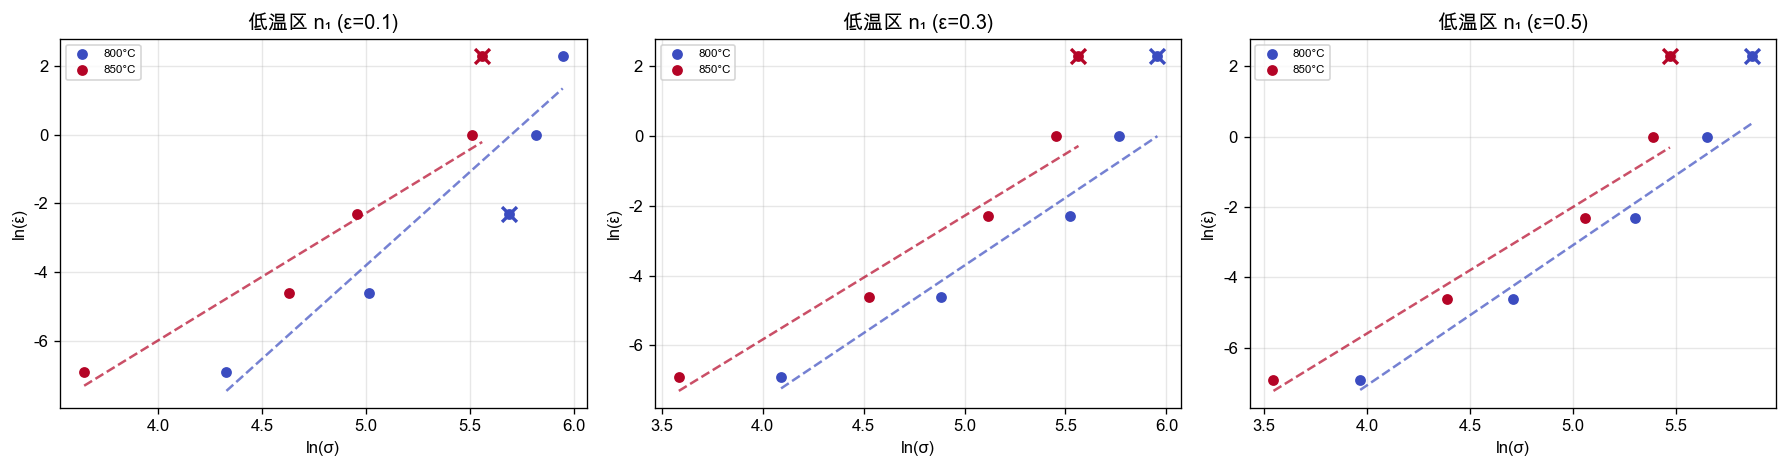

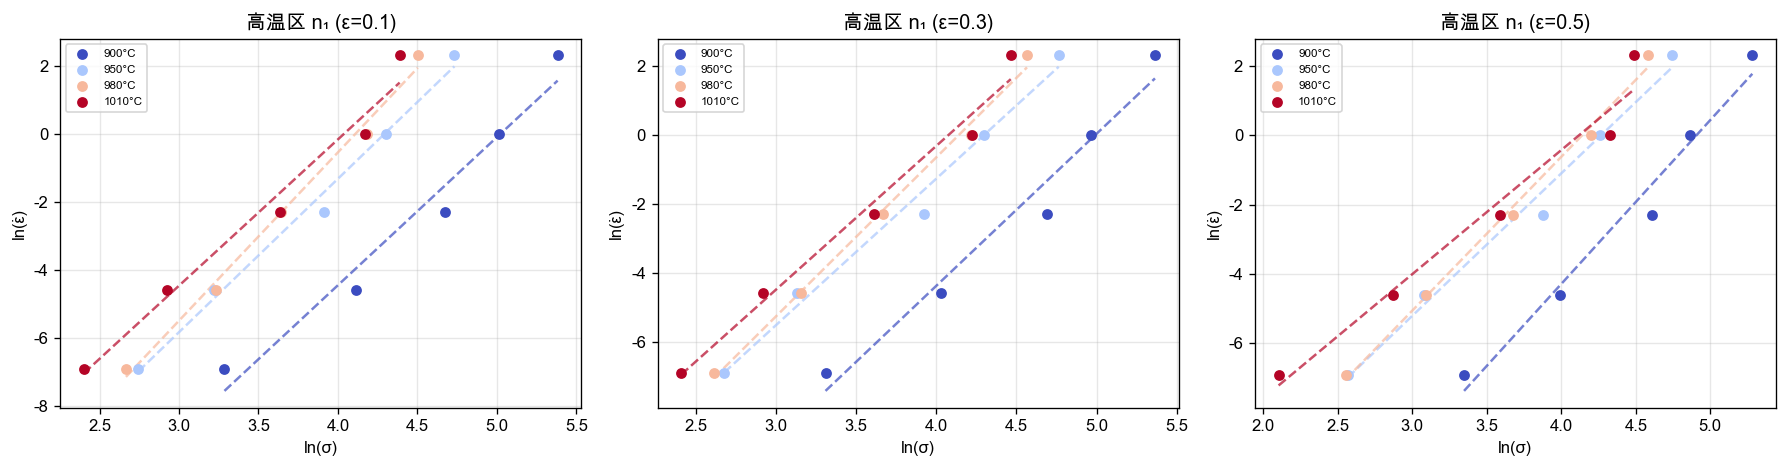

In [9]:
# 可视化 n₁ 拟合 (ln(σ) vs ln(ε̇))，选取典型应变点
sample_eps = [0.1, 0.3, 0.5]

for zone_name, df_disc, temps_list, params in [
    ('低温区', df_disc_low, temps_low, params_low),
    ('高温区', df_disc_high, temps_high, params_high)
]:
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(temps_list)))
    fig, axes = plt.subplots(1, len(sample_eps), figsize=(5*len(sample_eps), 4))
    for ax, eps in zip(axes, sample_eps):
        eps_r = round(eps, 4)
        for temp, c in zip(temps_list, colors):
            grp = df_disc[(np.isclose(df_disc['TrueStrain'], eps_r)) & (df_disc['Temperature'] == temp)]
            if len(grp) < 2:
                continue
            x = np.log(grp['FlowStress'].values)
            y = np.log(grp['StrainRate'].values)
            ax.scatter(x, y, color=c, label=f'{temp}°C', zorder=5, s=30)
            s, i_val, r2, mask = adaptive_linregress(x, y)
            x_fit = np.linspace(x.min(), x.max(), 50)
            ax.plot(x_fit, s * x_fit + i_val, '--', color=c, alpha=0.7)
            removed = x[~mask]
            if len(removed) > 0:
                ax.scatter(removed, y[~mask], color=c, marker='x', s=80, linewidths=2, zorder=6)
        ax.set_xlabel('ln(σ)'); ax.set_ylabel('ln(ε̇)')
        ax.set_title(f'{zone_name} n₁ (ε={eps})')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

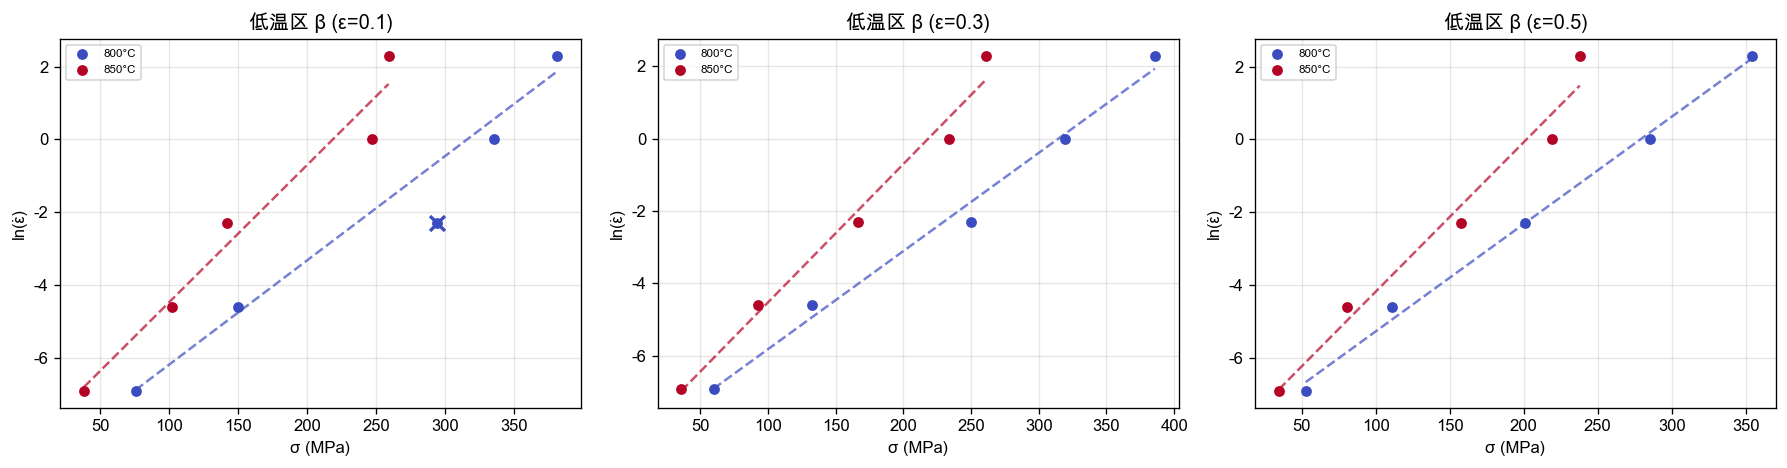

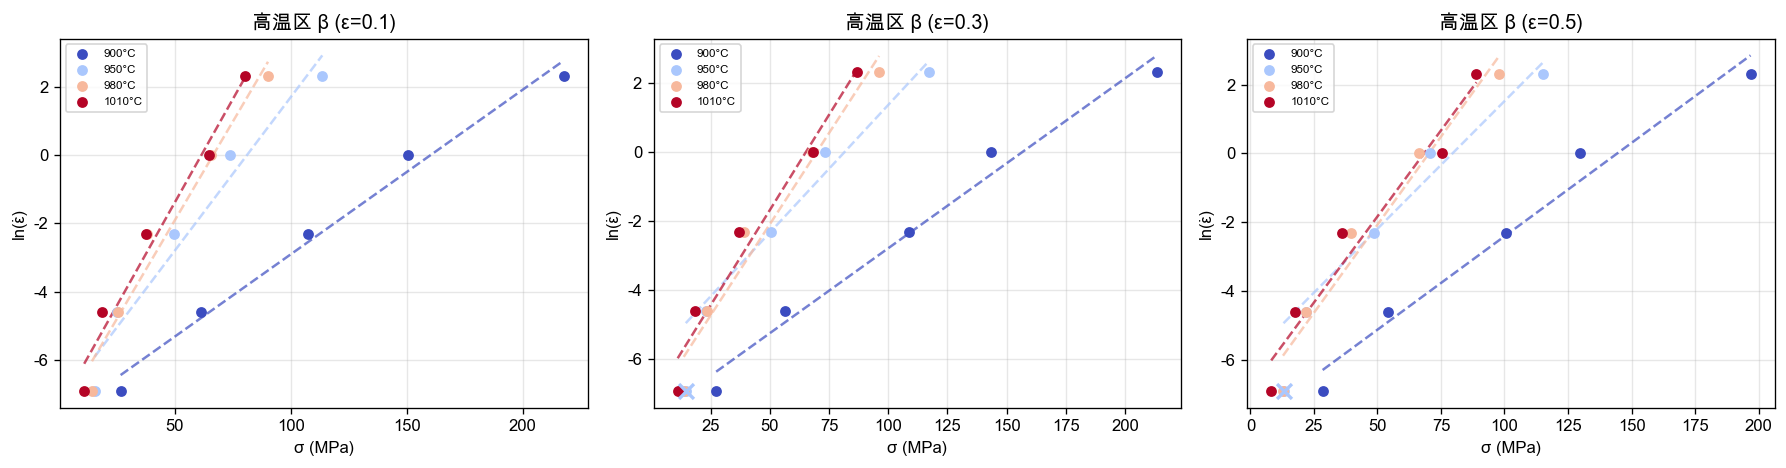

In [10]:
# 可视化 β 拟合 (σ vs ln(ε̇))
for zone_name, df_disc, temps_list, params in [
    ('低温区', df_disc_low, temps_low, params_low),
    ('高温区', df_disc_high, temps_high, params_high)
]:
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(temps_list)))
    fig, axes = plt.subplots(1, len(sample_eps), figsize=(5*len(sample_eps), 4))
    for ax, eps in zip(axes, sample_eps):
        eps_r = round(eps, 4)
        for temp, c in zip(temps_list, colors):
            grp = df_disc[(np.isclose(df_disc['TrueStrain'], eps_r)) & (df_disc['Temperature'] == temp)]
            if len(grp) < 2:
                continue
            x = grp['FlowStress'].values
            y = np.log(grp['StrainRate'].values)
            ax.scatter(x, y, color=c, label=f'{temp}°C', zorder=5, s=30)
            s, i_val, r2, mask = adaptive_linregress(x, y)
            x_fit = np.linspace(x.min(), x.max(), 50)
            ax.plot(x_fit, s * x_fit + i_val, '--', color=c, alpha=0.7)
            removed = x[~mask]
            if len(removed) > 0:
                ax.scatter(removed, y[~mask], color=c, marker='x', s=80, linewidths=2, zorder=6)
        ax.set_xlabel('σ (MPa)'); ax.set_ylabel('ln(ε̇)')
        ax.set_title(f'{zone_name} β (ε={eps})')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

### 4.2 Step 2.2 详细结果：主应力指数 n

In [11]:
for zone_name, params in [('低温区 (α+β)', params_low), ('高温区 (β)', params_high)]:
    print(f'\n===== {zone_name}: n（主应力指数）=====')
    print(f'{"ε":>6s} | {"n":>8s} | 各温度斜率（剔除点数）')
    print('-' * 80)
    for eps in sorted(params.keys()):
        p = params[eps]
        d = p['details']
        n_str = ', '.join([f'{t}:{s:.3f}(剔{d["n_removed"].get(t,0)})' for t, s in d['n_slopes'].items()])
        print(f'{eps:>6.2f} | {p["n"]:>8.4f} | {n_str}')


===== 低温区 (α+β): n（主应力指数）=====
     ε |        n | 各温度斜率（剔除点数）
--------------------------------------------------------------------------------
  0.10 |   3.2114 | 800:3.395(剔1), 850:3.028(剔1)
  0.15 |   3.3844 | 800:3.299(剔1), 850:3.470(剔0)
  0.20 |   2.9817 | 800:3.039(剔0), 850:2.924(剔1)
  0.25 |   2.7910 | 800:2.549(剔0), 850:3.033(剔0)
  0.30 |   2.9469 | 800:2.707(剔0), 850:3.187(剔0)
  0.35 |   2.9716 | 800:2.730(剔0), 850:3.213(剔0)
  0.40 |   2.9736 | 800:2.742(剔0), 850:3.205(剔0)
  0.45 |   2.9803 | 800:2.745(剔0), 850:3.216(剔0)
  0.50 |   2.7666 | 800:2.759(剔0), 850:2.774(剔1)
  0.55 |   3.1555 | 800:2.935(剔0), 850:3.376(剔0)
  0.60 |   2.9361 | 800:2.924(剔0), 850:2.948(剔1)
  0.65 |   2.9775 | 800:2.969(剔0), 850:2.986(剔1)

===== 高温区 (β): n（主应力指数）=====
     ε |        n | 各温度斜率（剔除点数）
--------------------------------------------------------------------------------
  0.10 |   3.2378 | 900:2.155(剔0), 950:3.299(剔0), 980:3.897(剔0), 1010:3.600(剔0)
  0.15 |   3.1872 | 900:2.147(剔0), 950:3.185

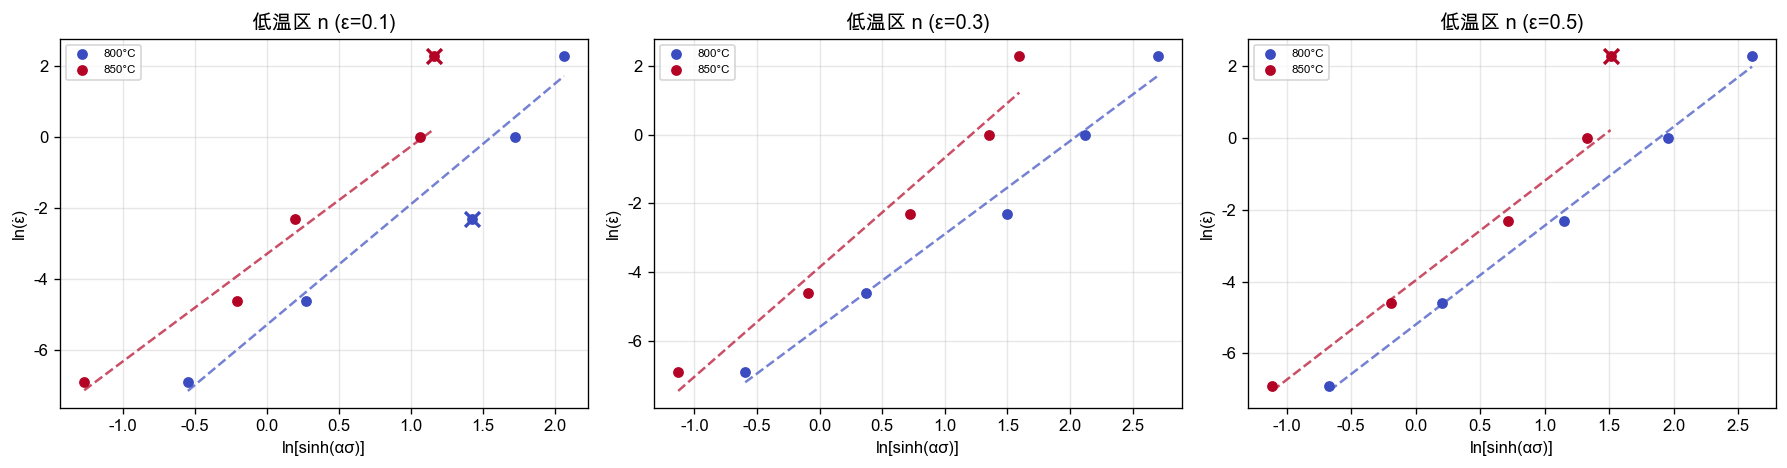

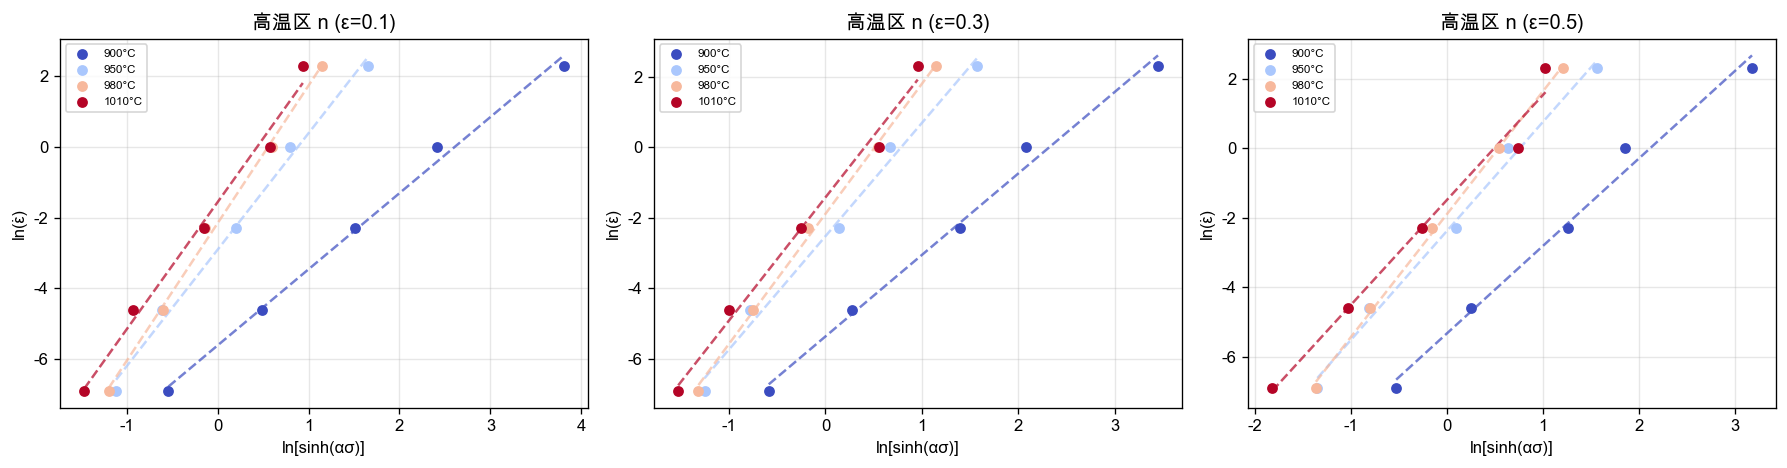

In [12]:
# 可视化 n 拟合 (ln[sinh(ασ)] vs ln(ε̇))
for zone_name, df_disc, temps_list, params in [
    ('低温区', df_disc_low, temps_low, params_low),
    ('高温区', df_disc_high, temps_high, params_high)
]:
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(temps_list)))
    fig, axes = plt.subplots(1, len(sample_eps), figsize=(5*len(sample_eps), 4))
    for ax, eps in zip(axes, sample_eps):
        eps_r = round(eps, 4)
        if eps_r not in params:
            continue
        alpha = params[eps_r]['alpha']
        for temp, c in zip(temps_list, colors):
            grp = df_disc[(np.isclose(df_disc['TrueStrain'], eps_r)) & (df_disc['Temperature'] == temp)]
            if len(grp) < 2:
                continue
            x = np.log(np.sinh(alpha * grp['FlowStress'].values))
            y = np.log(grp['StrainRate'].values)
            if np.all(np.isfinite(x)):
                ax.scatter(x, y, color=c, label=f'{temp}°C', zorder=5, s=30)
                s, i_val, r2, mask = adaptive_linregress(x, y)
                x_fit = np.linspace(x.min(), x.max(), 50)
                ax.plot(x_fit, s * x_fit + i_val, '--', color=c, alpha=0.7)
                removed_idx = np.where(~mask)[0]
                if len(removed_idx) > 0:
                    ax.scatter(x[removed_idx], y[removed_idx], color=c, marker='x', s=80, linewidths=2, zorder=6)
        ax.set_xlabel('ln[sinh(ασ)]'); ax.set_ylabel('ln(ε̇)')
        ax.set_title(f'{zone_name} n (ε={eps})')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

### 4.3 Step 2.3 详细结果：热变形激活能 Q

In [13]:
for zone_name, params in [('低温区 (α+β)', params_low), ('高温区 (β)', params_high)]:
    print(f'\n===== {zone_name}: Q（热变形激活能）=====')
    print(f'{"ε":>6s} | {"n":>8s} | {"S_avg":>10s} | {"Q(kJ/mol)":>12s} | 各速率斜率（剔除点数）')
    print('-' * 100)
    for eps in sorted(params.keys()):
        p = params[eps]
        d = p['details']
        s_str = ', '.join([f'{sr}:{s:.1f}(剔{d["S_removed"].get(sr,0)})' for sr, s in d['S_slopes'].items()])
        print(f'{eps:>6.2f} | {p["n"]:>8.4f} | {p["S"]:>10.1f} | {p["Q"]/1000:>12.2f} | {s_str}')


===== 低温区 (α+β): Q（热变形激活能）=====
     ε |        n |      S_avg |    Q(kJ/mol) | 各速率斜率（剔除点数）
----------------------------------------------------------------------------------------------------
  0.10 |   3.2114 |    19283.4 |       514.86 | 0.001:17361.6(剔0), 0.01:11630.1(剔0), 0.1:29648.0(剔0), 1.0:15944.6(剔0), 10.0:21832.8(剔0)
  0.15 |   3.3844 |    18562.5 |       522.32 | 0.001:16558.9(剔0), 0.01:11311.4(剔0), 0.1:27673.7(剔0), 1.0:15936.6(剔0), 10.0:21332.0(剔0)
  0.20 |   2.9817 |    18124.6 |       449.30 | 0.001:15595.9(剔0), 0.01:11195.9(剔0), 0.1:24595.8(剔0), 1.0:16246.8(剔0), 10.0:22988.5(剔0)
  0.25 |   2.7910 |    19639.4 |       455.72 | 0.001:14187.3(剔0), 0.01:11930.8(剔0), 0.1:23247.8(剔0), 1.0:19053.0(剔0), 10.0:29778.1(剔0)
  0.30 |   2.9469 |    17603.2 |       431.29 | 0.001:12906.8(剔0), 0.01:11194.4(剔0), 0.1:18689.7(剔0), 1.0:18511.8(剔0), 10.0:26713.1(剔0)
  0.35 |   2.9716 |    16524.1 |       408.24 | 0.001:12029.4(剔0), 0.01:10578.8(剔0), 0.1:16041.9(剔0), 1.0:17676.0(剔0), 10.0:26

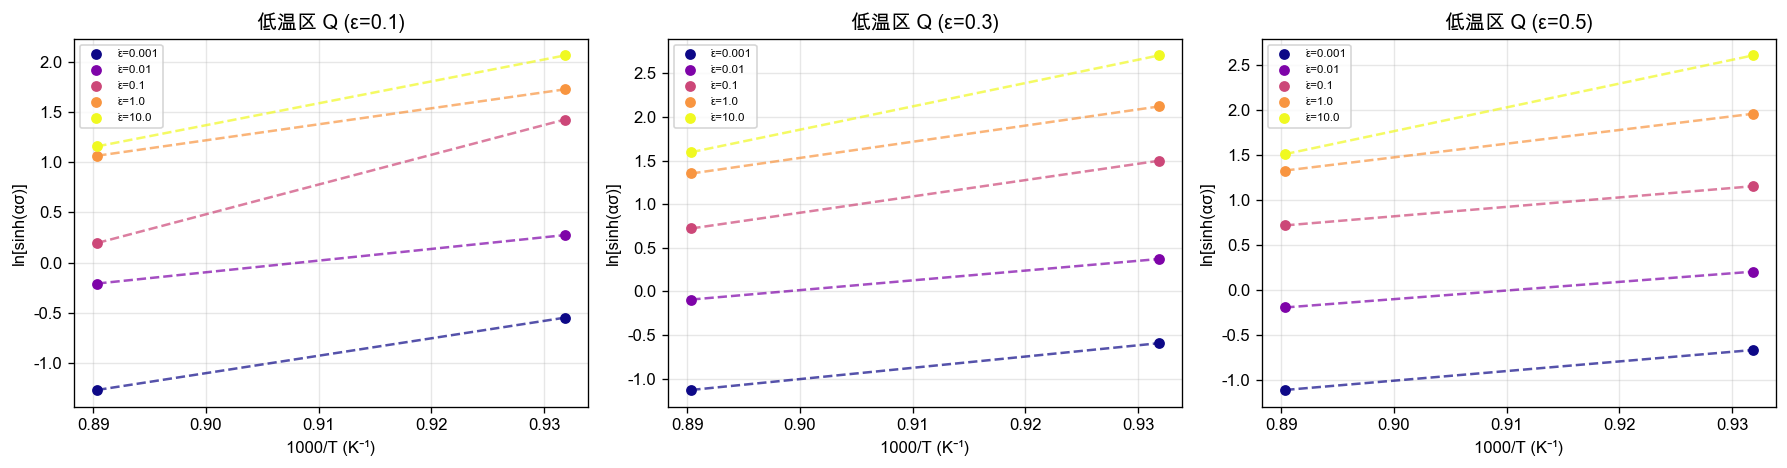

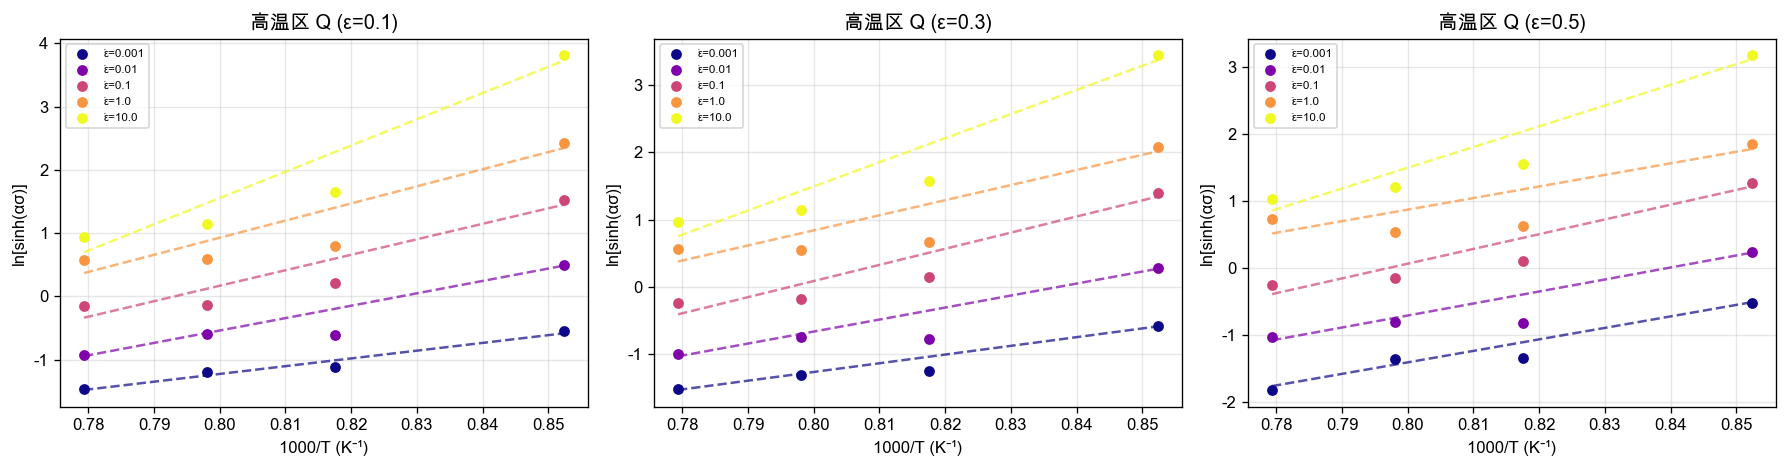

In [14]:
# 可视化 Q 拟合 (1/T vs ln[sinh(ασ)])
for zone_name, df_disc, temps_list, params in [
    ('低温区', df_disc_low, temps_low, params_low),
    ('高温区', df_disc_high, temps_high, params_high)
]:
    rc = plt.cm.plasma(np.linspace(0, 1, len(rates)))
    fig, axes = plt.subplots(1, len(sample_eps), figsize=(5*len(sample_eps), 4))
    for ax, eps in zip(axes, sample_eps):
        eps_r = round(eps, 4)
        if eps_r not in params:
            continue
        alpha = params[eps_r]['alpha']
        for sr_val, c in zip(rates, rc):
            grp = df_disc[(np.isclose(df_disc['TrueStrain'], eps_r)) & (df_disc['StrainRate'] == sr_val)]
            if len(grp) < 2:
                continue
            x = 1000.0 / grp['T_K'].values
            y = np.log(np.sinh(alpha * grp['FlowStress'].values))
            if np.all(np.isfinite(y)):
                ax.scatter(x, y, color=c, label=f'ε̇={sr_val}', zorder=5, s=30)
                s, i_val, r2, mask = adaptive_linregress(1.0/grp['T_K'].values, y)
                x_fit = np.linspace(x.min(), x.max(), 50)
                ax.plot(x_fit, s * x_fit / 1000 + i_val, '--', color=c, alpha=0.7)
        ax.set_xlabel('1000/T (K⁻¹)'); ax.set_ylabel('ln[sinh(ασ)]')
        ax.set_title(f'{zone_name} Q (ε={eps})')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

### 4.4 Step 2.4 详细结果：结构因子 ln A

In [15]:
for zone_name, params in [('低温区 (α+β)', params_low), ('高温区 (β)', params_high)]:
    print(f'\n===== {zone_name}: ln A =====')
    print(f'{"ε":>6s} | {"lnA":>10s} | {"R²":>8s} | {"剔除点":>6s} | {"回归斜率≈n":>12s}')
    print('-' * 60)
    for eps in sorted(params.keys()):
        p = params[eps]
        d = p['details']
        # 重新做一次回归来获取斜率信息
        sub = df_disc_low if '低温' in zone_name else df_disc_high
        sg = sub[np.isclose(sub['TrueStrain'], eps)]
        alpha = p['alpha']; Q = p['Q']
        sigma_all = sg['FlowStress'].values
        T_K_all = sg['T_K'].values
        sr_all = sg['StrainRate'].values
        ln_Z = np.log(sr_all) + Q / (R_GAS * T_K_all)
        x_all = np.log(np.sinh(alpha * sigma_all))
        valid = np.isfinite(ln_Z) & np.isfinite(x_all)
        slope_A, _, r2_A, _ = adaptive_linregress(x_all[valid], ln_Z[valid])
        print(f'{eps:>6.2f} | {p["lnA"]:>10.4f} | {d["lnA_r2"]:>8.4f} | {d["lnA_removed"]:>6d} | {slope_A:>12.4f}')


===== 低温区 (α+β): ln A =====
     ε |        lnA |       R² |    剔除点 |       回归斜率≈n
------------------------------------------------------------
  0.10 |    52.2484 |   0.9667 |      1 |       3.4887
  0.15 |    53.0338 |   0.9506 |      0 |       3.3011
  0.20 |    44.9847 |   0.9513 |      0 |       3.1745
  0.25 |    44.6990 |   0.9602 |      0 |       2.7514
  0.30 |    42.4760 |   0.9650 |      0 |       2.9089
  0.35 |    39.9862 |   0.9664 |      0 |       2.9326
  0.40 |    37.7026 |   0.9707 |      0 |       2.9369
  0.45 |    36.3255 |   0.9692 |      0 |       2.9413
  0.50 |    31.9921 |   0.9685 |      0 |       2.9396
  0.55 |    33.4724 |   0.9711 |      0 |       3.1222
  0.60 |    29.5807 |   0.9680 |      0 |       3.1193
  0.65 |    28.7081 |   0.9664 |      0 |       3.1690

===== 高温区 (β): ln A =====
     ε |        lnA |       R² |    剔除点 |       回归斜率≈n
------------------------------------------------------------
  0.10 |    62.1326 |   0.9596 |      4 |       3.65

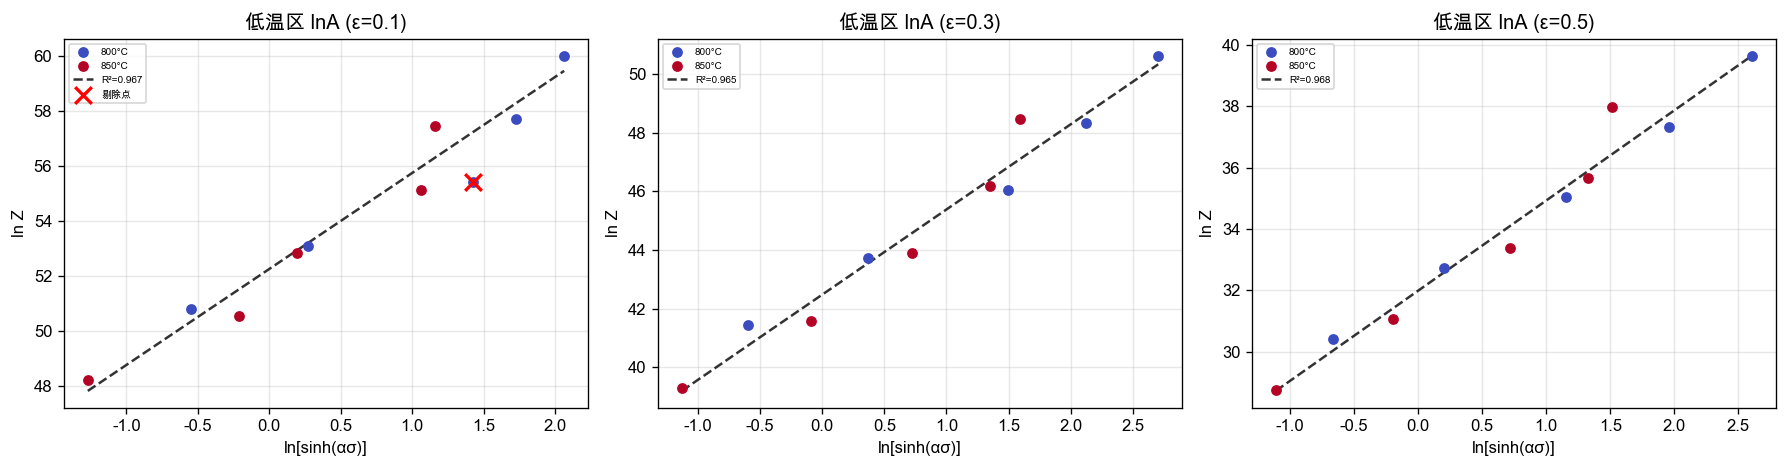

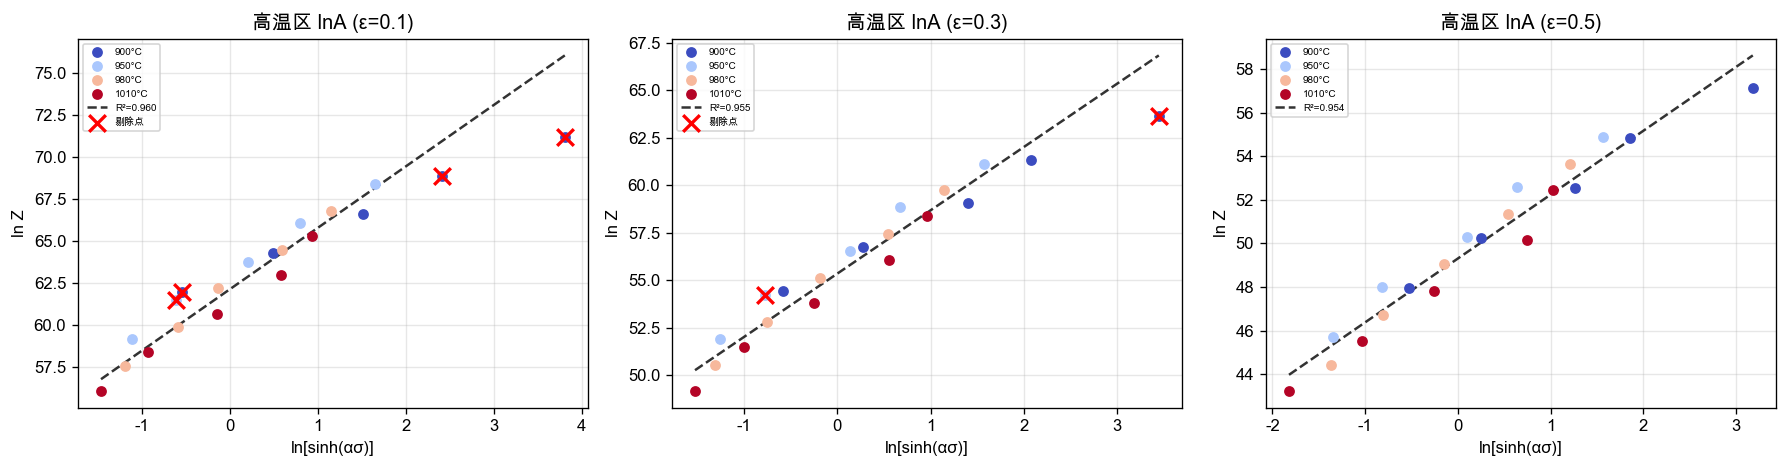

In [16]:
# 可视化 ln A 拟合 (ln[sinh(ασ)] vs ln Z)
for zone_name, df_disc, temps_list, params in [
    ('低温区', df_disc_low, temps_low, params_low),
    ('高温区', df_disc_high, temps_high, params_high)
]:
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(temps_list)))
    fig, axes = plt.subplots(1, len(sample_eps), figsize=(5*len(sample_eps), 4))
    for ax, eps in zip(axes, sample_eps):
        eps_r = round(eps, 4)
        if eps_r not in params:
            continue
        alpha = params[eps_r]['alpha']; Q = params[eps_r]['Q']
        sub = df_disc[np.isclose(df_disc['TrueStrain'], eps_r)]
        sigma = sub['FlowStress'].values
        T_K = sub['T_K'].values
        sr = sub['StrainRate'].values
        ln_Z = np.log(sr) + Q / (R_GAS * T_K)
        x = np.log(np.sinh(alpha * sigma))
        valid = np.isfinite(ln_Z) & np.isfinite(x)

        for temp, c in zip(temps_list, colors):
            mask_t = (sub['Temperature'].values == temp) & valid
            if mask_t.sum() > 0:
                ax.scatter(x[mask_t], ln_Z[mask_t], color=c, label=f'{temp}°C', zorder=5, s=30)

        s, i_val, r2, mask_r = adaptive_linregress(x[valid], ln_Z[valid])
        x_fit = np.linspace(x[valid].min(), x[valid].max(), 50)
        ax.plot(x_fit, s * x_fit + i_val, 'k--', alpha=0.8, label=f'R²={r2:.3f}')
        # 标记剔除的点
        removed_global = np.where(valid)[0][~mask_r]
        if len(removed_global) > 0:
            ax.scatter(x[removed_global], ln_Z[removed_global], color='red', marker='x', s=100, linewidths=2, zorder=6, label='剔除点')
        ax.set_xlabel('ln[sinh(ασ)]'); ax.set_ylabel('ln Z')
        ax.set_title(f'{zone_name} lnA (ε={eps})')
        ax.legend(fontsize=6); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

---
## 5. 参数汇总表

In [17]:
def params_to_df(params):
    rows = []
    for eps in sorted(params.keys()):
        p = params[eps]
        rows.append({'ε': eps, 'α': p['alpha'], 'n': p['n'],
                     'Q(kJ/mol)': p['Q']/1000, 'lnA': p['lnA']})
    return pd.DataFrame(rows)

print('===== 低温区 (α+β, <882°C) 参数汇总 =====')
pdf_low = params_to_df(params_low)
print(pdf_low.to_string(index=False))

print('\n===== 高温区 (β, ≥882°C) 参数汇总 =====')
pdf_high = params_to_df(params_high)
print(pdf_high.to_string(index=False))

===== 低温区 (α+β, <882°C) 参数汇总 =====
   ε        α        n  Q(kJ/mol)       lnA
0.10 0.007238 3.211394 514.858083 52.248439
0.15 0.007147 3.384430 522.315348 53.033833
0.20 0.007402 2.981662 449.299619 44.984721
0.25 0.009574 2.791022 455.723685 44.698970
0.30 0.008809 2.946900 431.286606 42.476016
0.35 0.008994 2.971554 408.236563 39.986206
0.40 0.009002 2.973595 386.228197 37.702562
0.45 0.009134 2.980307 373.047874 36.325458
0.50 0.009317 2.766648 333.090382 31.992060
0.55 0.008708 3.155466 343.047478 33.472405
0.60 0.008903 2.936079 307.433897 29.580709
0.65 0.009064 2.977470 299.417961 28.708065

===== 高温区 (β, ≥882°C) 参数汇总 =====
   ε        α        n  Q(kJ/mol)       lnA
0.10 0.020693 3.237835 671.904005 62.132594
0.15 0.020229 3.187232 655.805571 60.530899
0.20 0.020270 3.185489 642.303599 59.236707
0.25 0.020039 3.148210 619.422784 57.196821
0.30 0.019390 3.178386 598.363613 55.353001
0.35 0.019610 3.134456 580.616723 53.737249
0.40 0.019349 3.140663 567.177929 52.487677
0.45 0.

---
## 6. 第三阶段：5次多项式拟合（连续化处理）

In [18]:
POLY_DEG = 5

def fit_polynomials(params, label):
    eps_arr = np.array(sorted(params.keys()))
    alpha_arr = np.array([params[e]['alpha'] for e in eps_arr])
    n_arr     = np.array([params[e]['n']     for e in eps_arr])
    Q_arr     = np.array([params[e]['Q']     for e in eps_arr])
    lnA_arr   = np.array([params[e]['lnA']   for e in eps_arr])

    poly = {
        'alpha': np.polyfit(eps_arr, alpha_arr, POLY_DEG),
        'n':     np.polyfit(eps_arr, n_arr,     POLY_DEG),
        'Q':     np.polyfit(eps_arr, Q_arr,     POLY_DEG),
        'lnA':   np.polyfit(eps_arr, lnA_arr,   POLY_DEG),
    }

    print(f'\n===== {label}: {POLY_DEG}次多项式系数 =====')
    coeff_labels = [f'x^{i}' for i in range(POLY_DEG, -1, -1)]
    for name, coeffs in poly.items():
        print(f'\n{name}(ε):')
        for cl, cv in zip(coeff_labels, coeffs):
            print(f'  {cl}: {cv:>18.8e}')

    return poly, eps_arr, {
        'alpha': alpha_arr, 'n': n_arr,
        'Q': Q_arr, 'lnA': lnA_arr
    }

poly_low, eps_low, data_low = fit_polynomials(params_low, '低温区')
poly_high, eps_high, data_high = fit_polynomials(params_high, '高温区')


===== 低温区: 5次多项式系数 =====

alpha(ε):
  x^5:    -1.82005640e+00
  x^4:     3.68387828e+00
  x^3:    -2.76444181e+00
  x^2:     9.25496740e-01
  x^1:    -1.26520703e-01
  x^0:     1.29768349e-02

n(ε):
  x^5:     4.52202204e+02
  x^4:    -8.68890325e+02
  x^3:     6.13977813e+02
  x^2:    -1.91486979e+02
  x^1:     2.41183896e+01
  x^0:     2.23819080e+00

Q(ε):
  x^5:     2.44638388e+07
  x^4:    -4.60860742e+07
  x^3:     3.24955604e+07
  x^2:    -1.03792755e+07
  x^1:     1.00526133e+06
  x^0:     4.95494379e+05

lnA(ε):
  x^5:     3.52810089e+03
  x^4:    -6.75617640e+03
  x^3:     4.82250662e+03
  x^2:    -1.54596487e+03
  x^1:     1.63734544e+02
  x^0:     4.77829492e+01

===== 高温区: 5次多项式系数 =====

alpha(ε):
  x^5:    -5.59356280e-02
  x^4:     4.11415065e-02
  x^3:     2.30180672e-02
  x^2:    -1.63382317e-02
  x^1:    -2.32776553e-03
  x^0:     2.10179900e-02

n(ε):
  x^5:    -1.70144988e+02
  x^4:     3.11786794e+02
  x^3:    -2.15057725e+02
  x^2:     6.91684686e+01
  x^1:    -1

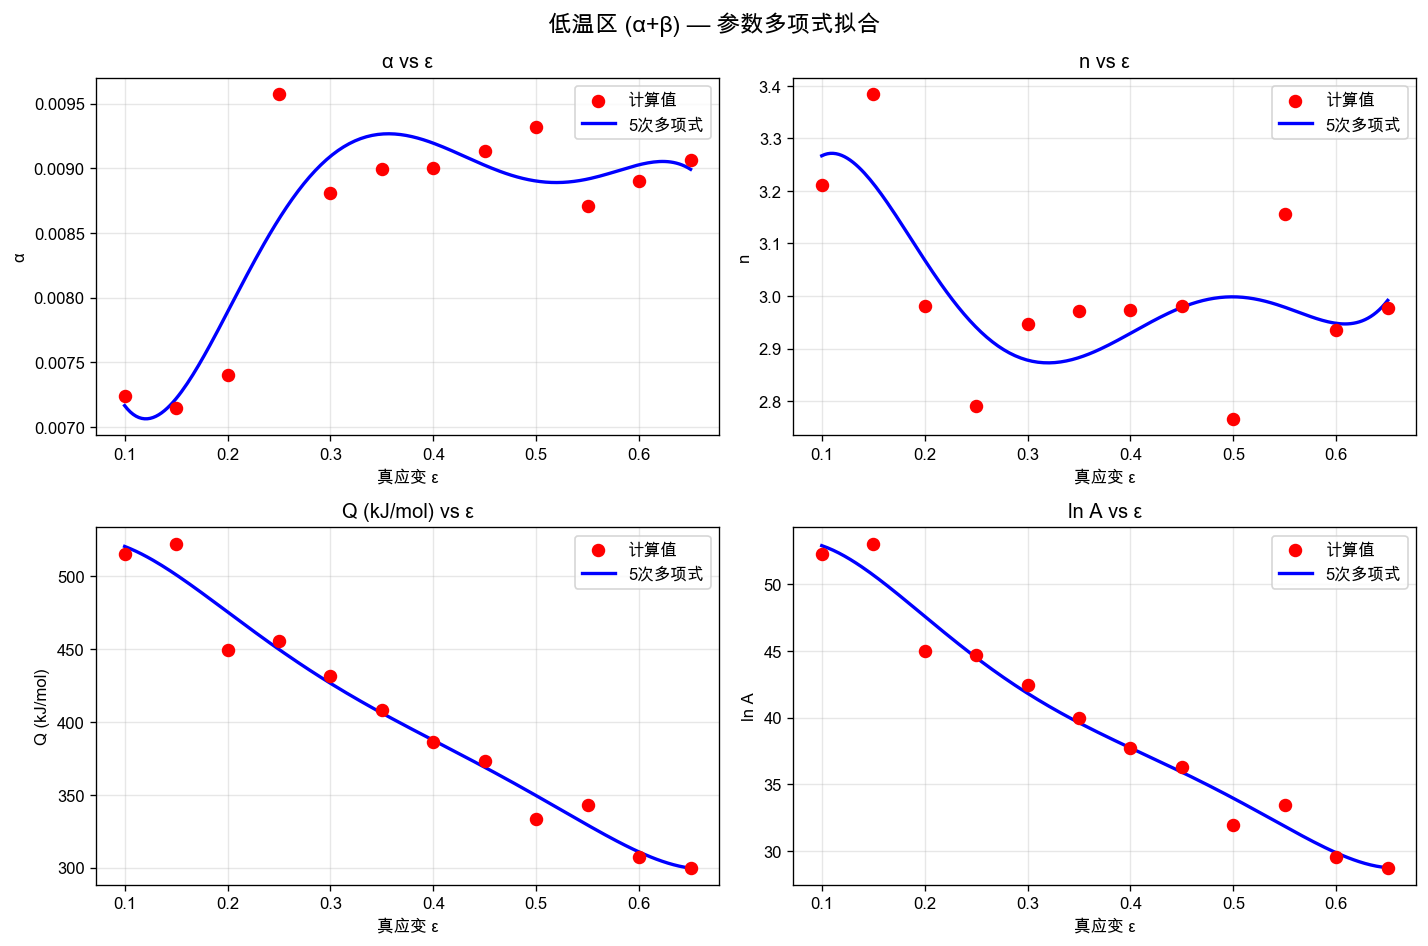

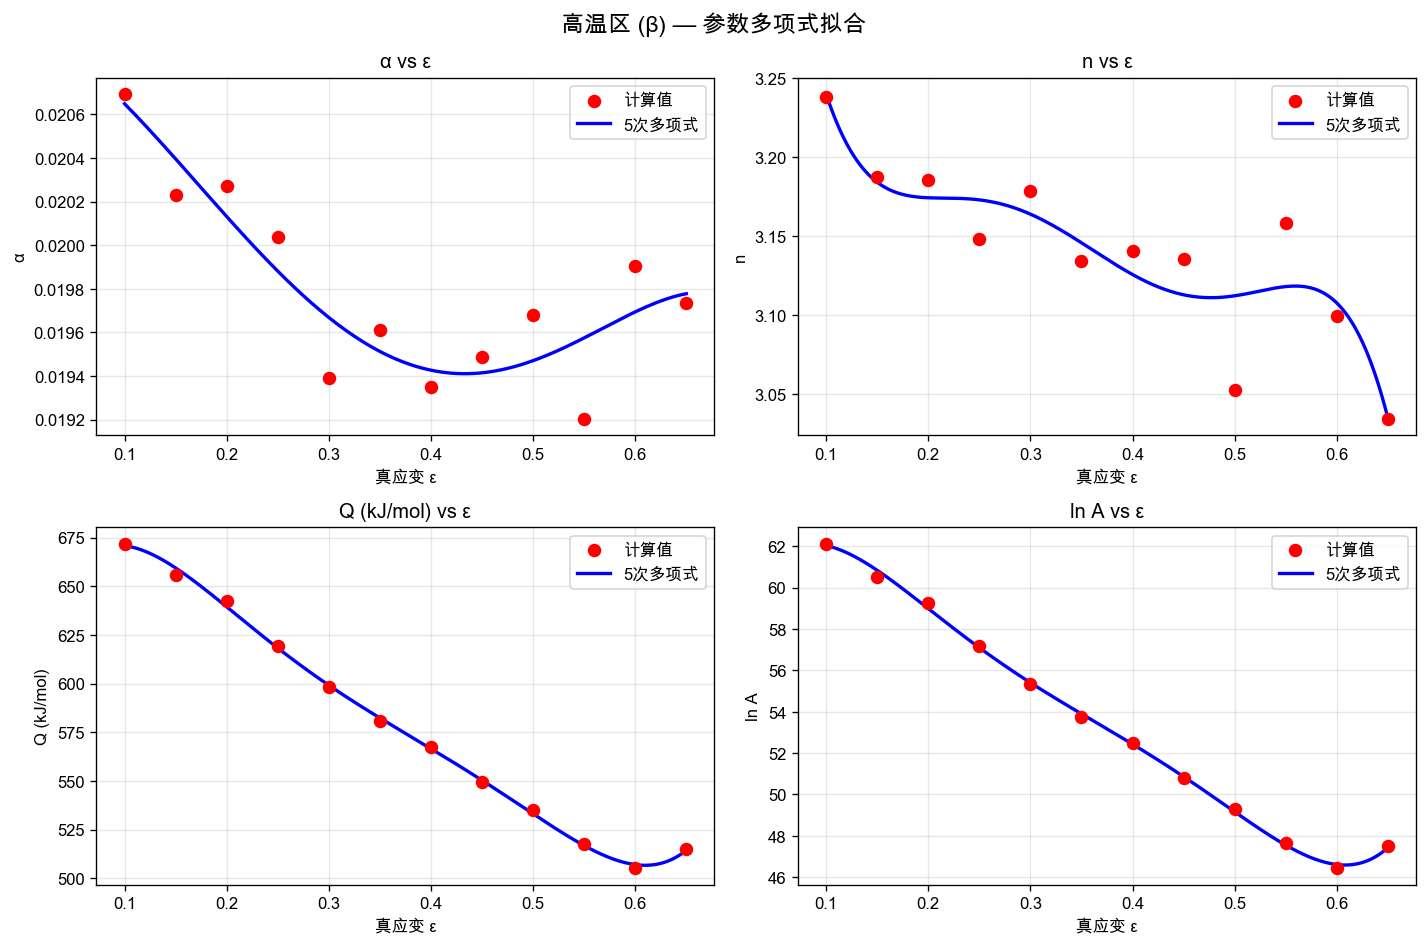

In [19]:
# 多项式拟合可视化
param_names = ['α', 'n', 'Q (kJ/mol)', 'ln A']
param_keys  = ['alpha', 'n', 'Q', 'lnA']
Q_scale     = [1, 1, 1/1000, 1]

for zone_label, poly, eps_arr, data_arr in [
    ('低温区 (α+β)', poly_low, eps_low, data_low),
    ('高温区 (β)', poly_high, eps_high, data_high)
]:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    eps_fine = np.linspace(eps_arr.min(), eps_arr.max(), 200)

    for ax, name, key, scale in zip(axes.flat, param_names, param_keys, Q_scale):
        y_data = data_arr[key] * scale
        y_fit  = np.polyval(poly[key], eps_fine) * scale
        ax.scatter(eps_arr, y_data, c='red', s=50, zorder=5, label='计算值')
        ax.plot(eps_fine, y_fit, 'b-', linewidth=2, label=f'{POLY_DEG}次多项式')
        ax.set_xlabel('真应变 ε'); ax.set_ylabel(name)
        ax.set_title(f'{name} vs ε'); ax.legend(); ax.grid(True, alpha=0.3)

    fig.suptitle(f'{zone_label} — 参数多项式拟合', fontsize=14)
    plt.tight_layout(); plt.show()

---
## 7. 第四阶段：分段模型预测与精度评估

In [20]:
def predict_stress(epsilon, strain_rate, T_K, poly):
    """单温区 Arrhenius 预测"""
    alpha = np.polyval(poly['alpha'], epsilon)
    n_val = np.polyval(poly['n'], epsilon)
    Q_val = np.polyval(poly['Q'], epsilon)
    lnA   = np.polyval(poly['lnA'], epsilon)

    ln_Z = np.log(strain_rate) + Q_val / (R_GAS * T_K)
    ln_Z_over_A = ln_Z - lnA
    x = np.exp(ln_Z_over_A / n_val)
    sigma = (1.0 / alpha) * np.log(x + np.sqrt(x**2 + 1))
    return sigma


def predict_segmented(epsilon, strain_rate, T_C, poly_low, poly_high):
    """分段预测：按相变边界选用不同参数"""
    T_K = T_C + 273.15
    if T_C < PHASE_BOUNDARY:
        return predict_stress(epsilon, strain_rate, T_K, poly_low)
    else:
        return predict_stress(epsilon, strain_rate, T_K, poly_high)


# 在离散点上评估
df_disc_all = pd.concat([df_disc_low, df_disc_high], ignore_index=True)
predictions = []

for _, row in df_disc_all.iterrows():
    eps = row['TrueStrain']
    T_C = row['Temperature']
    # 确保在拟合范围内
    eps_range = eps_low if T_C < PHASE_BOUNDARY else eps_high
    if eps < eps_range.min() or eps > eps_range.max():
        continue
    sigma_pred = predict_segmented(eps, row['StrainRate'], T_C, poly_low, poly_high)
    if np.isfinite(sigma_pred) and sigma_pred > 0:
        predictions.append({
            'Temperature': T_C, 'StrainRate': row['StrainRate'],
            'TrueStrain': eps, '实验值': row['FlowStress'],
            '预测值': sigma_pred,
            '误差%': abs(sigma_pred - row['FlowStress']) / row['FlowStress'] * 100,
            'Zone': '低温区' if T_C < PHASE_BOUNDARY else '高温区'
        })

pred_df = pd.DataFrame(predictions)

print('===== 分段模型整体精度 =====')
R_total = np.corrcoef(pred_df['实验值'], pred_df['预测值'])[0,1]
AARE_total = pred_df['误差%'].mean()
print(f'R = {R_total:.6f}')
print(f'R² = {R_total**2:.6f}')
print(f'AARE = {AARE_total:.2f}%')

print('\n--- 分温区精度 ---')
for zone in ['低温区', '高温区']:
    zdf = pred_df[pred_df['Zone'] == zone]
    if len(zdf) > 1:
        R_z = np.corrcoef(zdf['实验值'], zdf['预测值'])[0,1]
        print(f'{zone}: R={R_z:.4f}, R²={R_z**2:.4f}, AARE={zdf["误差%"].mean():.2f}%, n={len(zdf)}')

print('\n--- 各条件 AARE (ε=0.3) ---')
sample = pred_df[np.isclose(pred_df['TrueStrain'], 0.3)]
print(sample[['Temperature', 'StrainRate', '实验值', '预测值', '误差%', 'Zone']].to_string(index=False))

===== 分段模型整体精度 =====
R = 0.982461
R² = 0.965230
AARE = 14.40%

--- 分温区精度 ---
低温区: R=0.9765, R²=0.9535, AARE=9.56%, n=120
高温区: R=0.9671, R²=0.9353, AARE=16.84%, n=238

--- 各条件 AARE (ε=0.3) ---
 Temperature  StrainRate        实验值        预测值       误差% Zone
       800.0       0.001  59.840914  73.890924 23.478935  低温区
       800.0       0.010 132.361110 137.966944  4.235258  低温区
       800.0       0.100 249.956117 218.705870 12.502293  低温区
       800.0       1.000 319.629238 305.046695  4.562331  低温区
       800.0      10.000 385.713617 392.696240  1.810313  低温区
       850.0       0.001  36.067724  37.274603  3.346146  低温区
       850.0       0.010  92.711182  77.882148 15.994871  低温区
       850.0       0.100 166.730731 143.685124 13.822051  低温区
       850.0       1.000 233.907321 225.149875  3.743981  低温区
       850.0      10.000 260.944882 311.673875 19.440501  低温区
       900.0       0.001  27.378650  35.474218 29.568909  高温区
       900.0       0.010  56.355435  62.542441 10.978544  高温区
  

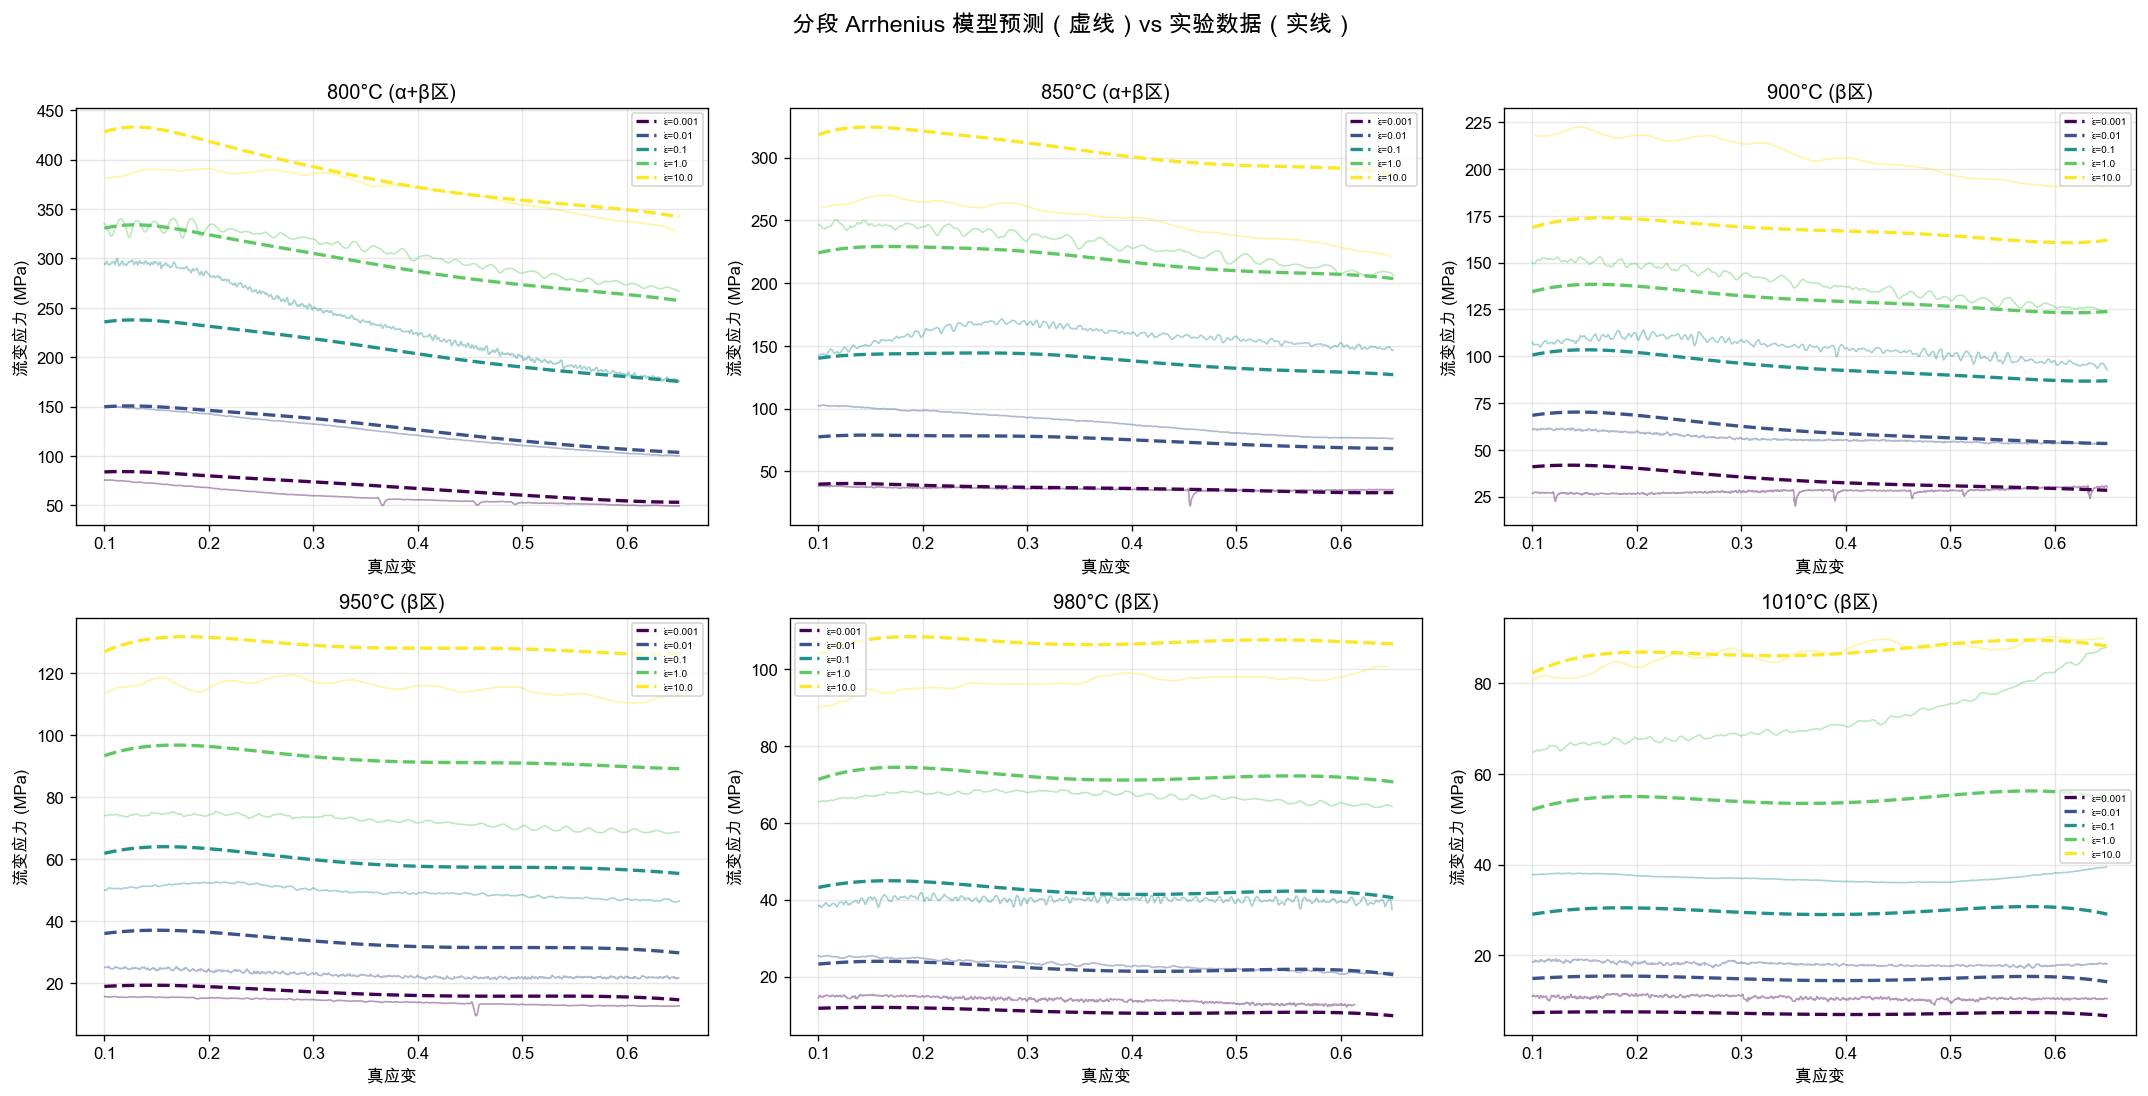

In [21]:
# 全曲线对比可视化
all_temps = sorted(df_all['Temperature'].unique())
rate_colors = plt.cm.viridis(np.linspace(0, 1, len(rates)))

n_cols = min(3, len(all_temps))
n_rows = (len(all_temps) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4.5*n_rows))
axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

for ax, temp in zip(axes_flat, all_temps):
    zone_label = 'α+β' if temp < PHASE_BOUNDARY else 'β'
    poly_use = poly_low if temp < PHASE_BOUNDARY else poly_high
    eps_range = eps_low if temp < PHASE_BOUNDARY else eps_high
    eps_pred = np.linspace(eps_range.min(), eps_range.max(), 100)

    for sr, c in zip(rates, rate_colors):
        exp = df_all[(df_all['Temperature']==temp) & (df_all['StrainRate']==sr)].sort_values('TrueStrain')
        exp = exp[(exp['TrueStrain'] >= eps_range.min()) & (exp['TrueStrain'] <= eps_range.max())]
        if len(exp) > 0:
            ax.plot(exp['TrueStrain'], exp['FlowStress'], '-', color=c, alpha=0.4, linewidth=1)

        T_K = temp + 273.15
        sigma_p = np.array([predict_stress(e, sr, T_K, poly_use) for e in eps_pred])
        valid = np.isfinite(sigma_p) & (sigma_p > 0)
        if valid.sum() > 0:
            ax.plot(eps_pred[valid], sigma_p[valid], '--', color=c, linewidth=2, label=f'ε̇={sr}')

    ax.set_title(f'{temp}°C ({zone_label}区)')
    ax.set_xlabel('真应变'); ax.set_ylabel('流变应力 (MPa)')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

for idx in range(len(all_temps), len(list(axes_flat))):
    list(axes_flat)[idx].set_visible(False)

fig.suptitle('分段 Arrhenius 模型预测（虚线）vs 实验数据（实线）', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

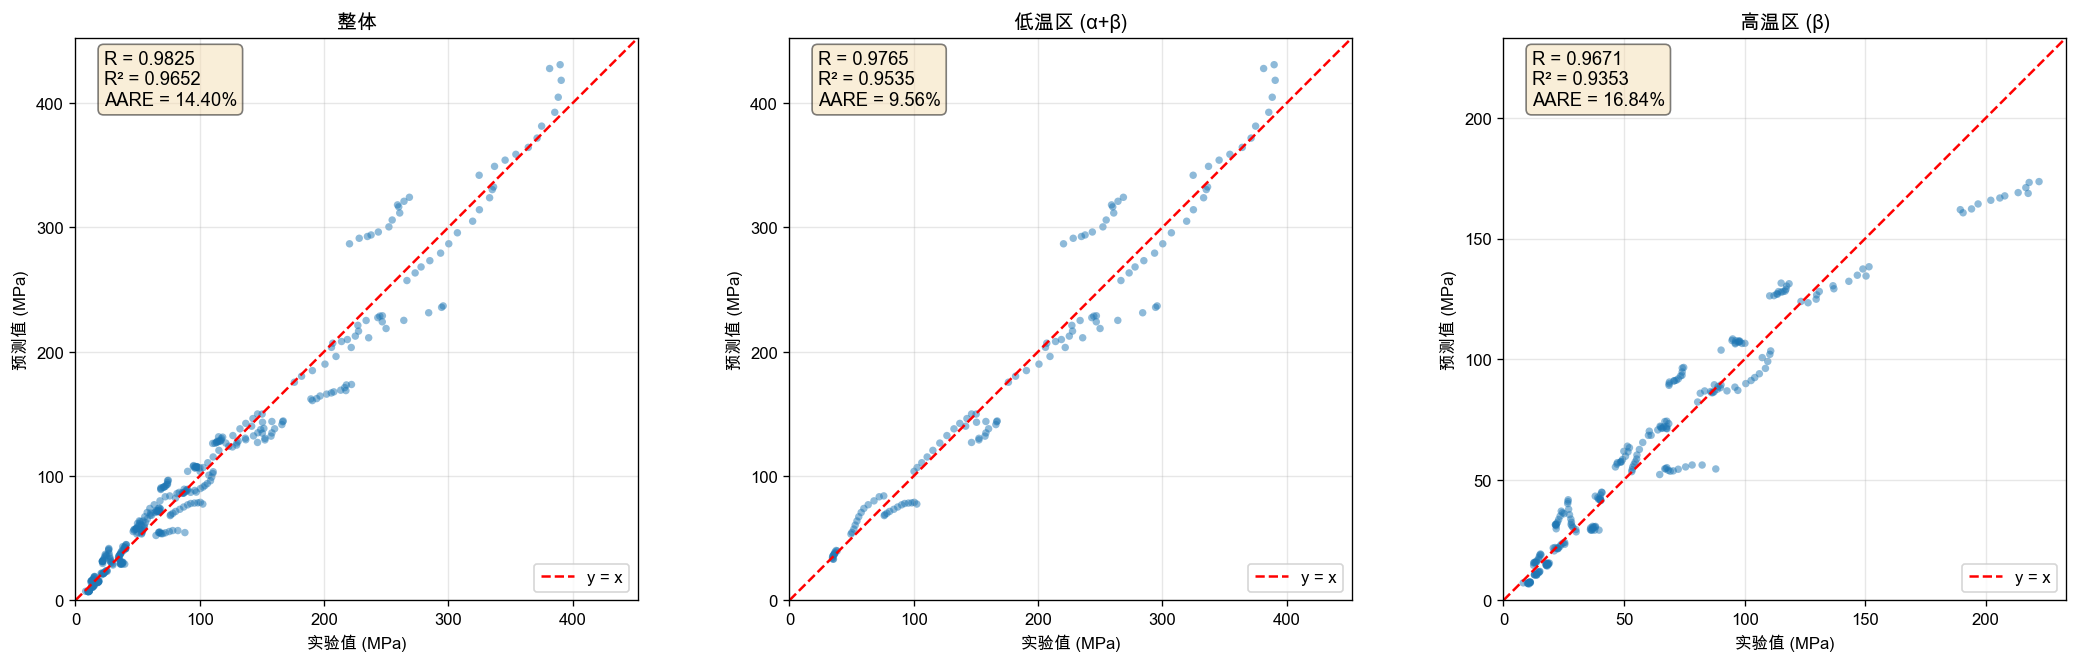


===== 最终模型评估 =====
整体 R = 0.982461, R² = 0.965230, AARE = 14.40%


In [22]:
# 预测值 vs 实验值 散点精度图
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (title, data) in zip(axes, [
    ('整体', pred_df),
    ('低温区 (α+β)', pred_df[pred_df['Zone']=='低温区']),
    ('高温区 (β)',   pred_df[pred_df['Zone']=='高温区'])
]):
    if len(data) < 2:
        ax.set_title(f'{title} — 数据不足'); continue

    ax.scatter(data['实验值'], data['预测值'], alpha=0.5, s=20, edgecolors='none')
    mx = max(data['实验值'].max(), data['预测值'].max()) * 1.05
    ax.plot([0, mx], [0, mx], 'r--', linewidth=1.5, label='y = x')

    R_val = np.corrcoef(data['实验值'], data['预测值'])[0, 1]
    AARE_val = data['误差%'].mean()
    ax.text(0.05, 0.88, f'R = {R_val:.4f}\nR² = {R_val**2:.4f}\nAARE = {AARE_val:.2f}%',
            transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_xlabel('实验值 (MPa)'); ax.set_ylabel('预测值 (MPa)')
    ax.set_title(title); ax.legend()
    ax.set_xlim(0, mx); ax.set_ylim(0, mx)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('\n===== 最终模型评估 =====')
print(f'整体 R = {R_total:.6f}, R² = {R_total**2:.6f}, AARE = {AARE_total:.2f}%')